# Zadanie 1

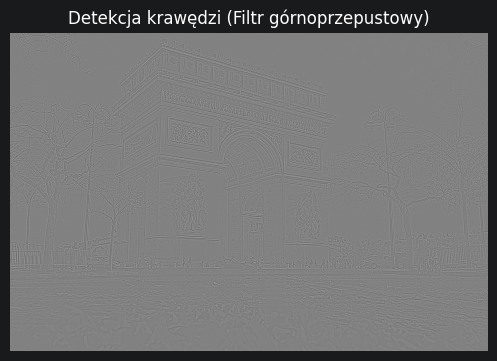

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_high_pass_filter(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    kernel = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ])

    filtered_image = cv2.filter2D(image, cv2.CV_64F, kernel)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 2)
    plt.imshow(filtered_image, cmap='gray')
    plt.title('Detekcja krawędzi (Filtr górnoprzepustowy)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

image = 'images/example.jpg'
apply_high_pass_filter(image)

# Zadanie 2

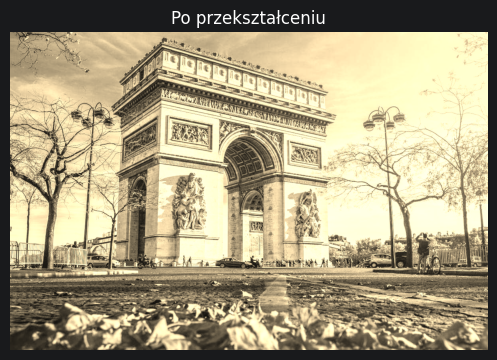

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_sepia_filter(image_path):
    # 1. Wczytanie obrazu
    image = cv2.imread(image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # konwersja na RGB

    image_float = image_rgb.astype(np.float32) / 255.0

    transformation_matrix = np.array([
        [0.393, 0.769, 0.189],
        [0.349, 0.689, 0.168],
        [0.272, 0.534, 0.131]
    ])

    image_transformed = np.dot(image_float, transformation_matrix.T)

    image_transformed = np.clip(image_transformed, 0.0, 1.0)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 2)
    plt.imshow(image_transformed)
    plt.title('Po przekształceniu')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

sciezka_do_pliku = 'images/example.jpg'
apply_sepia_filter(sciezka_do_pliku)

# Zadanie 3

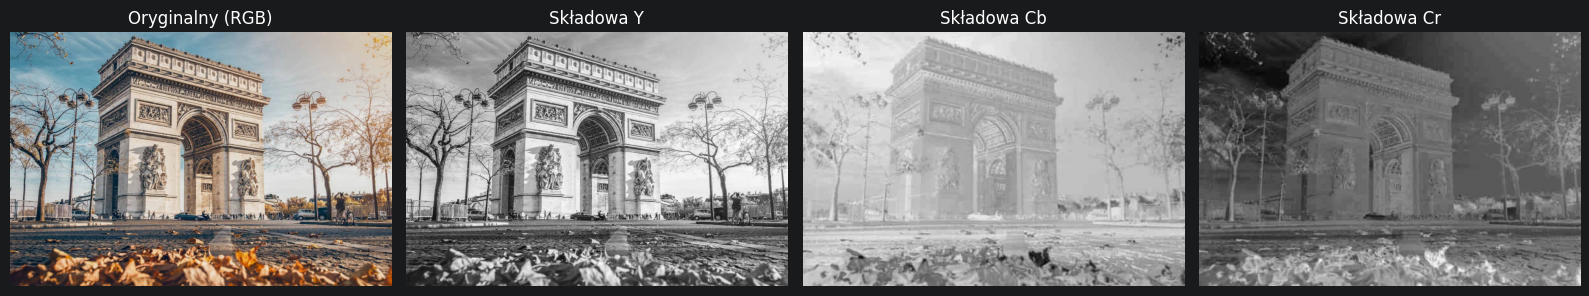

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import YcrcbConverter
def convert_to_ycrcb(image_path):

    imageYCrCb = YcrcbConverter.YcrcbConverter.convert(image_path)

    Y  = imageYCrCb[:, :, 0]
    Cr = imageYCrCb[:, :, 1]
    Cb = imageYCrCb[:, :, 2]
    plt.figure(figsize=(16, 4))
    imageRGB = cv2.cvtColor(imageYCrCb, cv2.COLOR_YCrCb2RGB)
    plt.subplot(1, 4, 1)
    plt.imshow(imageRGB)
    plt.title('Oryginalny (RGB)')
    plt.axis('off')

    # Składowa Y (Luminancja - Jasność)
    plt.subplot(1, 4, 2)
    plt.imshow(Y, cmap='gray')
    plt.title('Składowa Y')
    plt.axis('off')

    # Składowa Cb (Chrominancja - Różnica błękitu)
    plt.subplot(1, 4, 3)
    plt.imshow(Cb, cmap='gray')
    plt.title('Składowa Cb')
    plt.axis('off')

    # Składowa Cr (Chrominancja - Różnica czerwieni)
    plt.subplot(1, 4, 4)
    plt.imshow(Cr, cmap='gray')
    plt.title('Składowa Cr')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- URUCHOMIENIE KODU ---
sciezka_do_pliku = 'images/example.jpg'
convert_to_ycrcb(sciezka_do_pliku)

# Zadanie 4

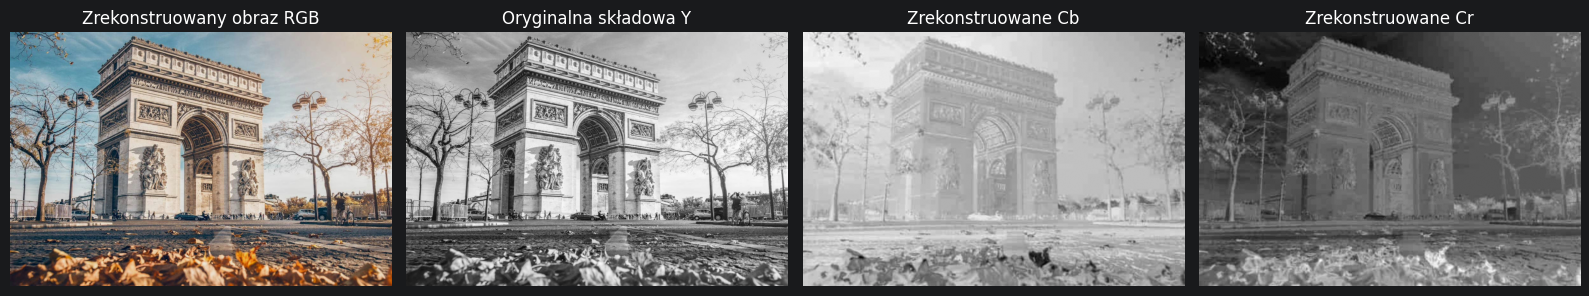

In [14]:
def simulate_dvb_transmission(image_path):
    imageYCrCb = YcrcbConverter.YcrcbConverter.convert(image_path)

    Y  = imageYCrCb[:, :, 0]
    Cr = imageYCrCb[:, :, 1]
    Cb = imageYCrCb[:, :, 2]

    H, W = Y.shape

    Cr_down = Cr[::2, ::2]
    Cb_down = Cb[::2, ::2]

    Cr_up = np.repeat(np.repeat(Cr_down, 2, axis=0), 2, axis=1)
    Cb_up = np.repeat(np.repeat(Cb_down, 2, axis=0), 2, axis=1)

    Cr_up = Cr_up[:H, :W]
    Cb_up = Cb_up[:H, :W]

    image_ycrcb_decoded = cv2.merge([Y, Cr_up, Cb_up])

    image_rgb_decoded = cv2.cvtColor(image_ycrcb_decoded, cv2.COLOR_YCrCb2RGB)

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image_rgb_decoded)
    plt.title('Zrekonstruowany obraz RGB')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(Y, cmap='gray')
    plt.title('Oryginalna składowa Y')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(Cb_up, cmap='gray')
    plt.title('Zrekonstruowane Cb')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(Cr_up, cmap='gray')
    plt.title('Zrekonstruowane Cr')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

sciezka_do_pliku = 'images/example.jpg'
simulate_dvb_transmission(sciezka_do_pliku)

# Zadanie 5

In [17]:
import cv2
import numpy as np
import os

def calculate_mse(imageA, imageB):
    imgA_float = imageA.astype("float")
    imgB_float = imageB.astype("float")

    diff_squared = (imgA_float - imgB_float) ** 2

    mse_value = np.mean(diff_squared)
    return mse_value

def main(path_png, path_jpg):
    img_png_bgr = cv2.imread(path_png)
    img_jpg_bgr = cv2.imread(path_jpg)

    img_png_rgb = cv2.cvtColor(img_png_bgr, cv2.COLOR_BGR2RGB)
    img_jpg_rgb = cv2.cvtColor(img_jpg_bgr, cv2.COLOR_BGR2RGB)

    bias = np.array([0, 128, 128])
    matrix = np.array([[0.229, 0.587, 0.114], [0.500, -0.418, -0.082], [-0.168, -0.331, 0.500]])
    ycrcb = np.clip(np.dot(img_png_rgb.astype(np.float32), matrix.T) + bias, 0, 255).astype(np.uint8)

    Y, Cr, Cb = ycrcb[:,:,0], ycrcb[:,:,1], ycrcb[:,:,2]

    Cr_reconstructed = np.repeat(np.repeat(Cr[::2, ::2], 2, axis=0), 2, axis=1)[:Y.shape[0], :Y.shape[1]]
    Cb_reconstructed = np.repeat(np.repeat(Cb[::2, ::2], 2, axis=0), 2, axis=1)[:Y.shape[0], :Y.shape[1]]

    ycrcb_decoded = cv2.merge([Y, Cr_reconstructed, Cb_reconstructed])
    image_rgb_decoded = cv2.cvtColor(ycrcb_decoded, cv2.COLOR_YCrCb2RGB)

    mse_dvb = calculate_mse(img_png_rgb, image_rgb_decoded)
    print(f"1. Błąd MSE po symulacji DVB (podpróbkowanie Cr i Cb): {mse_dvb:.2f}")

    mse_jpeg = calculate_mse(img_png_rgb, img_jpg_rgb)
    print(f"2. Błąd MSE między oryginalnym PNG a formatem JPG: {mse_jpeg:.2f}")

    mse_png = calculate_mse(img_png_rgb, img_png_rgb)
    print(f"3. Błąd MSE między oryginalnym PNG a formatem PNG (bezstratnym): {mse_png:.2f}")

jpg = 'images/example.jpg'
png = 'images/example.png'
main(png,jpg)

1. Błąd MSE po symulacji DVB (podpróbkowanie Cr i Cb): 163.68
2. Błąd MSE między oryginalnym PNG a formatem JPG: 0.00
3. Błąd MSE między oryginalnym PNG a formatem PNG (bezstratnym): 0.00
